In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv('GlobalWeatherRepository.csv')

# Convert time feature for time-series analysis
df['last_updated'] = pd.to_datetime(df['last_updated'])

print(f"Dataset Loaded. Shape: {df.shape}")
df.head()

Dataset Loaded. Shape: (139753, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


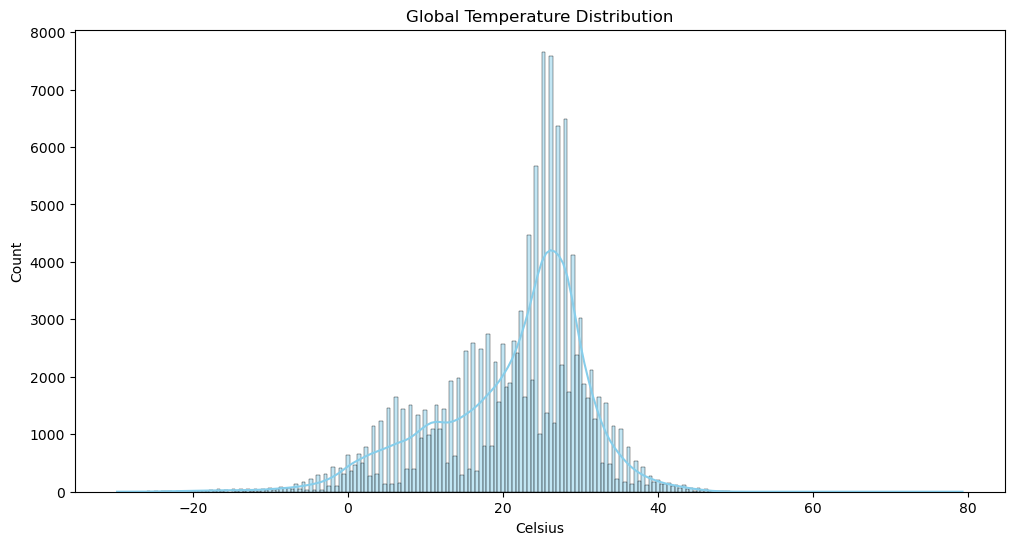

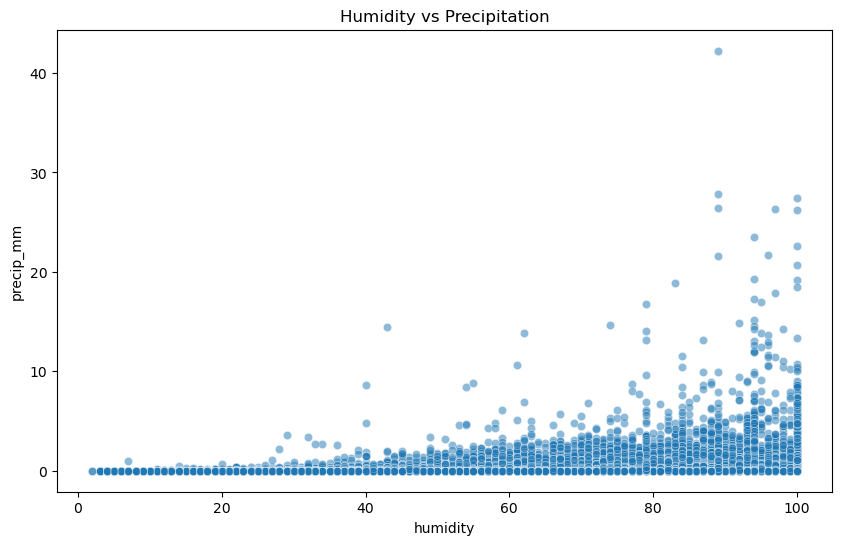

In [3]:
# Temperature Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['temperature_celsius'], kde=True, color='skyblue')
plt.title('Global Temperature Distribution')
plt.xlabel('Celsius')
plt.show()

# Precipitation vs Humidity Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='humidity', y='precip_mm', alpha=0.5)
plt.title('Humidity vs Precipitation')
plt.show()

In [4]:
# Feature Selection
features = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb', 'cloud']
target = 'feels_like_celsius'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation
predictions = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.4f}")
print(f"R-Squared Score: {r2_score(y_test, predictions):.4f}")

Mean Absolute Error: 0.4300
R-Squared Score: 0.9927


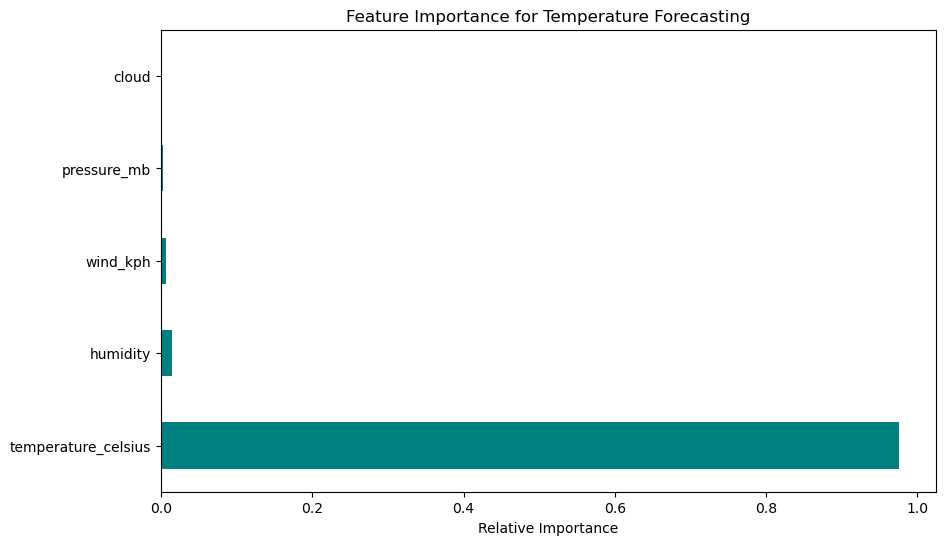

In [5]:
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='teal')
plt.title('Feature Importance for Temperature Forecasting')
plt.xlabel('Relative Importance')
plt.show()

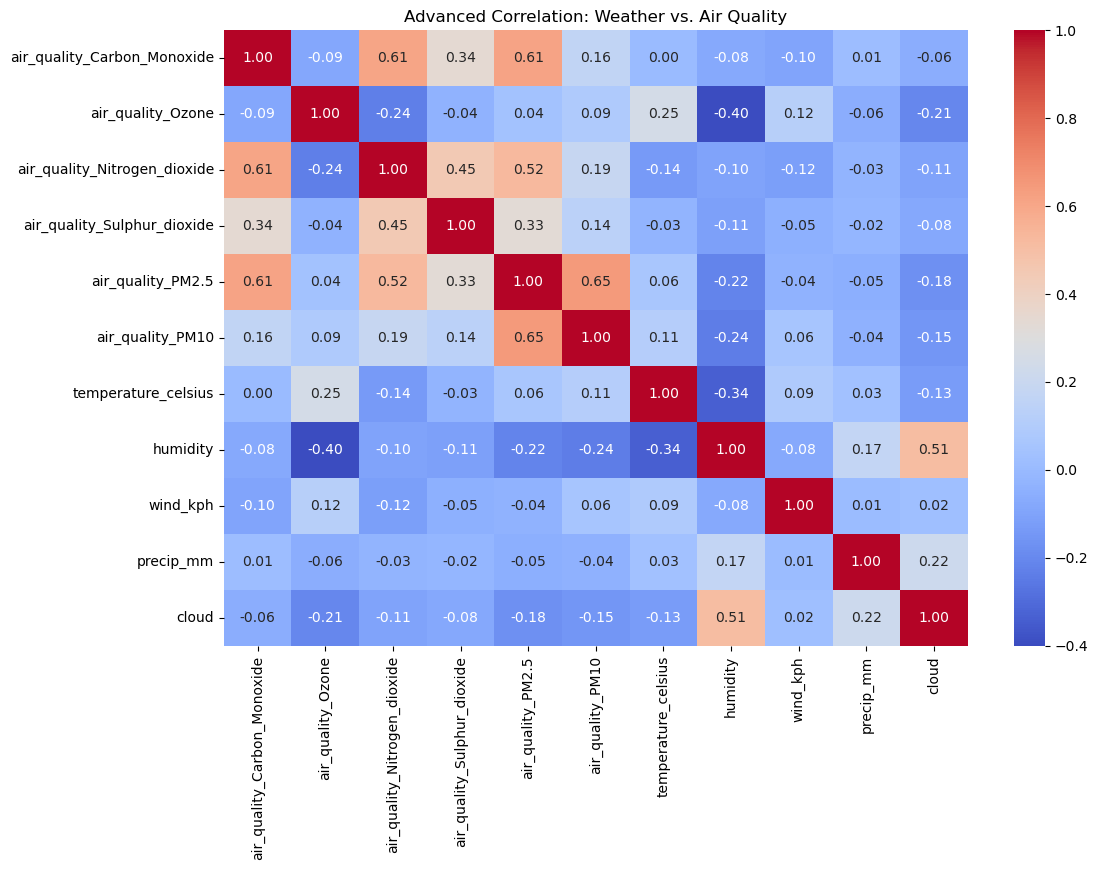

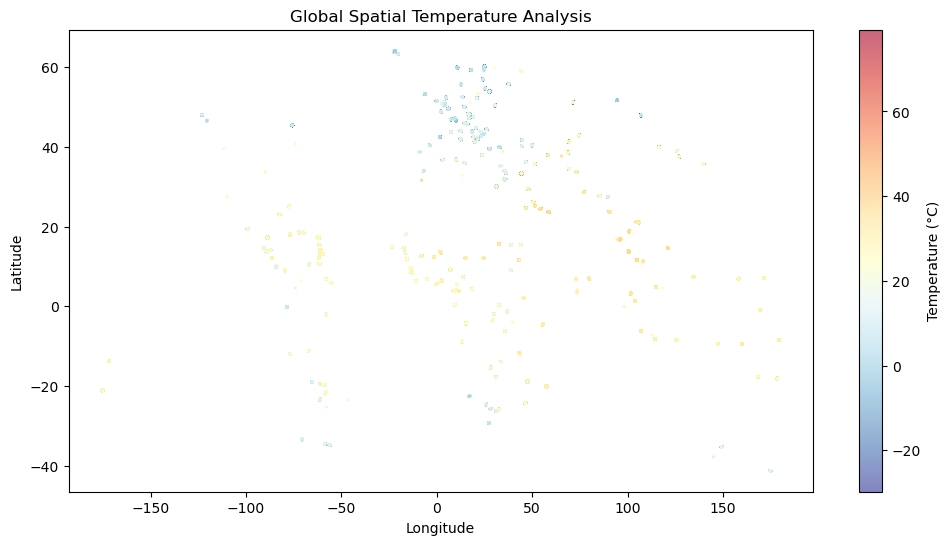

In [6]:
# Correlation between Weather and Air Quality
aq_cols = [col for col in df.columns if 'air_quality' in col and 'index' not in col]
weather_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm', 'cloud']

plt.figure(figsize=(12, 8))
sns.heatmap(df[aq_cols + weather_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Advanced Correlation: Weather vs. Air Quality')
plt.show()

# Geographical Temperature Mapping
plt.figure(figsize=(12, 6))
plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'], cmap='RdYlBu_r', s=2, alpha=0.6)
plt.colorbar(label='Temperature (°C)')
plt.title('Global Spatial Temperature Analysis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [8]:
# Advance Analysis

from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the individual models
model_lr = LinearRegression()
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Create the Ensemble (averages the results of both models)
ensemble_model = VotingRegressor(estimators=[
    ('linear_reg', model_lr), 
    ('random_forest', model_rf)
])

# 3. Train and Predict
ensemble_model.fit(X_train, y_train)
ensemble_preds = ensemble_model.predict(X_test)

# 4. Final Comparison
print(f"Ensemble Mean Absolute Error: {mean_absolute_error(y_test, ensemble_preds):.4f}")
print(f"Ensemble R2 Score: {r2_score(y_test, ensemble_preds):.4f}")

Ensemble Mean Absolute Error: 0.7798
Ensemble R2 Score: 0.9897
